### Load Dataset

In [17]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
sms_df = pd.read_csv('data/sms.tsv', sep='\t', header=None, 
                    names=['label', 'message'])
sms_df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
sms_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [20]:
print(sms_df.shape, '\n')
print(sms_df.isna().sum(), '\n')
print(sms_df.duplicated().sum(), '\n')
print(sms_df['label'].value_counts(normalize=True), '\n')

(5572, 3) 

label      0
message    0
length     0
dtype: int64 

403 

label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64 



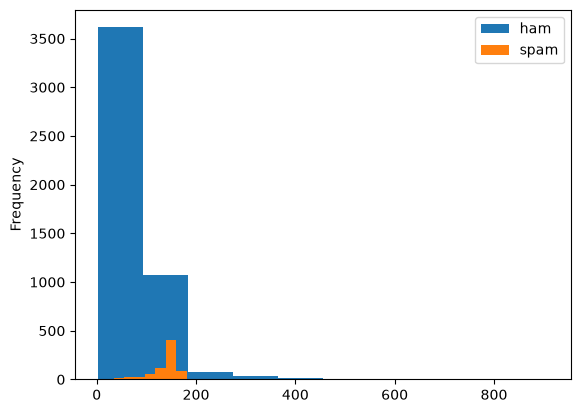

In [18]:
sms_df['length'] = sms_df['message'].str.len()
sms_df.groupby('label')['length'].plot(kind='hist', legend=True)

plt.show()

- Shape (5572, 3)
- Imbalance in target col.
- 400+ duplicates but no null values.
- Ham are variable and range from 0-400 and mostly around 0-50 whereas the spam are around 10-200 and mostly around 180.


In [22]:
# remove duplicates
sms_df = sms_df.drop_duplicates() 

### Vectorize

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(
    sms_df['message'], sms_df['label'], test_size=0.2, random_state=42,
    stratify=sms_df['label']
)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [29]:
X_train_vec.shape

(4135, 7680)

### Train Model

In [71]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def run_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(accuracy_score(y_test, y_pred), '\n')
    print(classification_report(y_test, y_pred), '\n')
    print(confusion_matrix(y_test, y_pred), '\n')

    return model

#### Naive Bayes

In [69]:
from sklearn.naive_bayes import MultinomialNB

nb_model = run_model(MultinomialNB(), X_train_vec, X_test_vec, y_train, y_test)
nb_model

0.9526112185686654 

              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       903
        spam       1.00      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.96      0.95      0.95      1034
 

[[903   0]
 [ 49  82]] 



,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3613., 522.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.07]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U4](2,)","['ham','spam']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7680)","[[0. ,0. ,0.23,...,0.18,0. ,0.3 ], [1.56,5.22,0. ,...,0. ,0.22,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7680)","[[-9.85,-9.85,-9.64,...,-9.68,-9.85,-9.59], [-8.27,-7.38,-9.21,...,-9.21,-9.01,-9.21]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7680


#### Logistic

In [68]:
from sklearn.linear_model import LogisticRegression

lr_model = run_model(LogisticRegression(class_weight="balanced"), X_train_vec, X_test_vec, y_train, y_test)
lr_model

0.9738878143133463 

              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       903
        spam       0.88      0.92      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.95      0.94      1034
weighted avg       0.97      0.97      0.97      1034
 

[[887  16]
 [ 11 120]] 



,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [60]:
feature_names = vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

print("Spam")
for idx, (word, coef) in enumerate(
    sorted(zip(feature_names, coefficients), key=lambda x: x[1], reverse=True)[:5], 1):
    print(f"{idx}. {word.title()}: {coef}")

print("\nHam")
for idx, (word, coef) in enumerate(
    sorted(zip(feature_names, coefficients), key=lambda x: x[1])[:5], 1):
    print(f"{idx}. {word.title()}: {coef}")

Spam
1. Call: 5.1303839342974324
2. Txt: 4.641807134618913
3. Text: 3.9386813460624492
4. Reply: 3.708612504982841
5. Free: 3.5706247919972522

Ham
1. My: -2.7670061663010896
2. Me: -2.6587977978233153
3. That: -2.0251524315148064
4. Gt: -1.8308067326406303
5. Lt: -1.8264180657309546


### Combine

In [79]:
import scipy
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
length_scaled_train = scaler.fit_transform(sms_df.loc[X_train.index, 'length'].values.reshape(-1, 1))
length_scaled_test = scaler.transform(sms_df.loc[X_test.index, 'length'].values.reshape(-1, 1))

X_train_comb = scipy.sparse.hstack([X_train_vec, length_scaled_train])
X_test_comb = scipy.sparse.hstack([X_test_vec, length_scaled_test])

In [80]:
comb_lr_model = run_model(
    LogisticRegression(class_weight="balanced"), 
    X_train_comb, X_test_comb, y_train, y_test
)

0.9642166344294004 

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       903
        spam       0.85      0.88      0.86       131

    accuracy                           0.96      1034
   macro avg       0.91      0.93      0.92      1034
weighted avg       0.96      0.96      0.96      1034
 

[[882  21]
 [ 16 115]] 

